In [22]:
# using SparseArrays
# using LinearAlgebra
# using Plots

# # -----------------------
# # Material parameters
# # -----------------------
# #E  = 1.0
# #ν  = 0.3

# λ = 1.0 #E*ν/(1-ν^2)          # plane stress
# μ = 0.1 #E/(2*(1+ν))

# # Poisson ratio
# ν = λ/(2*(λ + μ))

# # -----------------------
# # Grid
# # -----------------------
# Nx = 5
# Ny = 5
# Lx = 1.0
# Ly = 1.0
# hx = Lx/(Nx-1)
# hy = Ly/(Ny-1)

# N = Nx*Ny
# Ndof = 2*N

# function idx(i,j,c)
#     node = (j-1)*Nx + i
#     return 2*(node-1) + c
# end

# rows = Int[]
# cols = Int[]
# vals = Float64[]
# b    = zeros(Ndof)

# function add(i,j,v)
#     push!(rows,i)
#     push!(cols,j)
#     push!(vals,v)
# end

# ε0 = 0.1

# # -----------------------
# # Assembly
# # -----------------------
# for j in 1:Ny
# for i in 1:Nx

#     # -------- Left boundary (fixed) --------
#     if i == 1
#         for comp in 1:2
#             row = idx(i,j,comp)
#             add(row,row,1.0)
#             b[row] = 0.0
#         end
#         continue
#     end

#     # -------- Right boundary (stretch) --------
#     if i == Nx
#         # a1 prescribed
#         row = idx(i,j,1)
#         add(row,row,1.0)
#         b[row] = ε0

#         # a2 free (natural already satisfied)
#         row = idx(i,j,2)
#         add(row,row,1.0)
#         b[row] = 0.0
#         continue
#     end

#     # -------- Bottom traction free --------
#     if j == 1
#         # σ_yy = 0
#         row = idx(i,j,2)

#         add(row, idx(i,j+1,2),  (λ+2μ)/hy)
#         add(row, idx(i,j,2),   -(λ+2μ)/hy)
#         add(row, idx(i+1,j,1),  λ/(2hx))
#         add(row, idx(i-1,j,1), -λ/(2hx))

#         # σ_xy = 0
#         row = idx(i,j,1)
#         add(row, idx(i,j+1,1),  μ/hy)
#         add(row, idx(i,j,1),   -μ/hy)
#         add(row, idx(i+1,j,2),  μ/(2hx))
#         add(row, idx(i-1,j,2), -μ/(2hx))
#         continue
#     end

#     # -------- Top traction free --------
#     if j == Ny
#         # σ_yy = 0
#         row = idx(i,j,2)

#         add(row, idx(i,j,2),    (λ+2μ)/hy)
#         add(row, idx(i,j-1,2), -(λ+2μ)/hy)
#         add(row, idx(i+1,j,1),  λ/(2hx))
#         add(row, idx(i-1,j,1), -λ/(2hx))

#         # σ_xy = 0
#         row = idx(i,j,1)
#         add(row, idx(i,j,1),    μ/hy)
#         add(row, idx(i,j-1,1), -μ/hy)
#         add(row, idx(i+1,j,2),  μ/(2hx))
#         add(row, idx(i-1,j,2), -μ/(2hx))
#         continue
#     end

#     # -------- Interior Navier equation --------
#     for comp in 1:2
#         row = idx(i,j,comp)

#         if comp == 1
#             add(row, idx(i,j,1), -2*(λ+2μ)/hx^2 - 2*μ/hy^2)
#             add(row, idx(i+1,j,1),(λ+2μ)/hx^2)
#             add(row, idx(i-1,j,1),(λ+2μ)/hx^2)
#             add(row, idx(i,j+1,1),μ/hy^2)
#             add(row, idx(i,j-1,1),μ/hy^2)

#             coeff = (λ+μ)/(4hx*hy)
#             add(row, idx(i+1,j+1,2),  coeff)
#             add(row, idx(i+1,j-1,2), -coeff)
#             add(row, idx(i-1,j+1,2), -coeff)
#             add(row, idx(i-1,j-1,2),  coeff)
#         else
#             add(row, idx(i,j,2), -2*(λ+2μ)/hy^2 - 2*μ/hx^2)
#             add(row, idx(i,j+1,2),(λ+2μ)/hy^2)
#             add(row, idx(i,j-1,2),(λ+2μ)/hy^2)
#             add(row, idx(i+1,j,2),μ/hx^2)
#             add(row, idx(i-1,j,2),μ/hx^2)

#             coeff = (λ+μ)/(4hx*hy)
#             add(row, idx(i+1,j+1,1),  coeff)
#             add(row, idx(i+1,j-1,1), -coeff)
#             add(row, idx(i-1,j+1,1), -coeff)
#             add(row, idx(i-1,j-1,1),  coeff)
#         end
#     end

# end
# end

# M = sparse(rows,cols,vals,Ndof,Ndof)

# u = M \ b

# a1 = reshape(u[1:2:end],Nx,Ny)
# a2 = reshape(u[2:2:end],Nx,Ny)

In [128]:
using SparseArrays
using LinearAlgebra
using Plots

# -----------------------
# Material parameters
# -----------------------
λ = 1.0
μ = 1.0

ν = λ/(2*(λ + μ))
println("Poisson ratio = ", ν)

# -----------------------
# Grid
# -----------------------
Nx = 50
Ny = 50
Lx = 1.0
Ly = 1.0
hx = Lx/(Nx-1)
hy = Ly/(Ny-1)

N = Nx*Ny
Ndof = 2*N

# -------- Blocked ordering ----------
# First N entries → a1
# Next  N entries → a2

function idx(i,j,c)
    node = (j-1)*Nx + i
    if c == 1
        return node
    else
        return node + N
    end
end

rows = Int[]
cols = Int[]
vals = Float64[]
b    = zeros(Ndof)

function add(i,j,v)
    push!(rows,i)
    push!(cols,j)
    push!(vals,v)
end

ε0 = 0.2

# -----------------------
# Assembly
# -----------------------
for j in 1:Ny
for i in 1:Nx

    # -------- Left boundary (fixed) --------
    if i == 1
        for comp in 1:2
            row = idx(i,j,comp)
            add(row,row,1.0)
            b[row] = 0.0
        end
        continue
    end

    # -------- Right boundary (stretch) --------
    if i == Nx
        # prescribe a1
        row = idx(i,j,1)
        add(row,row,1.0)
        b[row] = ε0

        # a2 
        row = idx(i,j,2)
        add(row,row,1.0)
        b[row] = 0.0        
        continue
    end

    # -------- Bottom traction free --------
    if j == 1
        # σ_yy = 0
        row = idx(i,j,2)
        add(row, idx(i,j+1,2),  (λ+2μ)/hy)
        add(row, idx(i,j,2),   -(λ+2μ)/hy)
        add(row, idx(i+1,j,1),  λ/(2hx))
        add(row, idx(i-1,j,1), -λ/(2hx))

        # σ_xy = 0
        row = idx(i,j,1)
        add(row, idx(i,j+1,1),  μ/hy)
        add(row, idx(i,j,1),   -μ/hy)
        add(row, idx(i+1,j,2),  μ/(2hx))
        add(row, idx(i-1,j,2), -μ/(2hx))
        continue
    end

    # -------- Top traction free --------
    if j == Ny
        # σ_yy = 0
        row = idx(i,j,2)
        add(row, idx(i,j,2),    (λ+2μ)/hy)
        add(row, idx(i,j-1,2), -(λ+2μ)/hy)
        add(row, idx(i+1,j,1),  λ/(2hx))
        add(row, idx(i-1,j,1), -λ/(2hx))

        # σ_xy = 0
        row = idx(i,j,1)
        add(row, idx(i,j,1),    μ/hy)
        add(row, idx(i,j-1,1), -μ/hy)
        add(row, idx(i+1,j,2),  μ/(2hx))
        add(row, idx(i-1,j,2), -μ/(2hx))
        continue
    end

    # -------- Interior Navier equation --------
    for comp in 1:2
        row = idx(i,j,comp)

        if comp == 1
            add(row, idx(i,j,1), -2*(λ+2μ)/hx^2 - 2*μ/hy^2)
            add(row, idx(i+1,j,1),(λ+2μ)/hx^2)
            add(row, idx(i-1,j,1),(λ+2μ)/hx^2)
            add(row, idx(i,j+1,1),μ/hy^2)
            add(row, idx(i,j-1,1),μ/hy^2)

            coeff = (λ+μ)/(4hx*hy)
            add(row, idx(i+1,j+1,2),  coeff)
            add(row, idx(i+1,j-1,2), -coeff)
            add(row, idx(i-1,j+1,2), -coeff)
            add(row, idx(i-1,j-1,2),  coeff)

        else
            add(row, idx(i,j,2), -2*(λ+2μ)/hy^2 - 2*μ/hx^2)
            add(row, idx(i,j+1,2),(λ+2μ)/hy^2)
            add(row, idx(i,j-1,2),(λ+2μ)/hy^2)
            add(row, idx(i+1,j,2),μ/hx^2)
            add(row, idx(i-1,j,2),μ/hx^2)

            coeff = (λ+μ)/(4hx*hy)
            add(row, idx(i+1,j+1,1),  coeff)
            add(row, idx(i+1,j-1,1), -coeff)
            add(row, idx(i-1,j+1,1), -coeff)
            add(row, idx(i-1,j-1,1),  coeff)
        end
    end

end
end

# -----------------------
# Solve
# -----------------------
M = sparse(rows,cols,vals,Ndof,Ndof)
u = M \ b

# Extract solution (blocked format)
a1 = reshape(u[1:N], Nx, Ny)
a2 = reshape(u[N+1:end], Nx, Ny)

Poisson ratio = 0.25


50×50 Matrix{Float64}:
 0.0         0.0         0.0         0.0         …   0.0          0.0
 0.00731303  0.00492264  0.00372561  0.00306664     -0.00492264  -0.00731303
 0.00993714  0.00859548  0.00719676  0.00614962     -0.00859548  -0.00993714
 0.0131007   0.0116264   0.0102132   0.0089952      -0.0116264   -0.0131007
 0.0155743   0.0142206   0.0128311   0.0115441      -0.0142206   -0.0155743
 0.0178079   0.0164797   0.0151186   0.0138075   …  -0.0164797   -0.0178079
 0.01976     0.0184658   0.0171301   0.0158141      -0.0184658   -0.01976
 0.0214966   0.0202224   0.0189073   0.0175944      -0.0202224   -0.0214966
 0.0230402   0.0217814   0.0204825   0.0191755      -0.0217814   -0.0230402
 0.024416    0.0231677   0.0218813   0.0205807      -0.0231677   -0.024416
 0.0256424   0.0244013   0.0231244   0.0218295   …  -0.0244013   -0.0256424
 0.0267349   0.0254987   0.0242287   0.0229388      -0.0254987   -0.0267349
 0.0277066   0.0264733   0.0252084   0.0239225      -0.0264733   -0.0277

In [129]:
i = 50
M[i,:]

5000-element SparseVector{Float64, Int64} with 1 stored entry:
  [50]  =  1.0

In [130]:
b[i]

0.2

Measured Poisson ratio ≈ 0.3276012756450275
Theoretical ν = 0.25


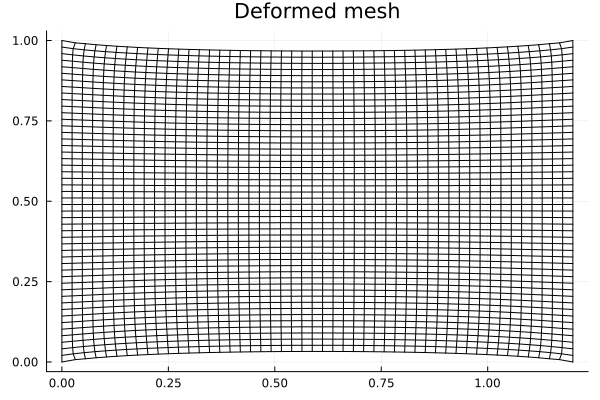

In [131]:
# -----------------------
# Check Poisson squeeze
# -----------------------
mid = div(Ny,2)
εx = (a1[end,mid] - a1[1,mid]) / Lx
εy = (a2[mid,Ny] - a2[mid,1]) / Ly

println("Measured Poisson ratio ≈ ", -εy/εx)
println("Theoretical ν = ", ν)

# -----------------------
# Plot deformation
# -----------------------
x = range(0,Lx,length=Nx)
y = range(0,Ly,length=Ny)

X = [xi for xi in x, yi in y]
Y = [yi for xi in x, yi in y]

scale = 1  # exaggerate deformation for visualization

p = plot()
for j in 1:Ny
    plot!(p, X[:,j] .+ scale*a1[:,j],
              Y[:,j] .+ scale*a2[:,j],
              color=:black,
              legend=false)
end
for i in 1:Nx
    plot!(p, X[i,:] .+ scale*a1[i,:],
              Y[i,:] .+ scale*a2[i,:],
              color=:black,
              legend=false)
end

title!(p,"Deformed mesh")
display(p)

In [5]:
using SparseArrays
using LinearAlgebra

# -----------------------
# Parameters
# -----------------------
λ = 1.0
μ = 1.0
T = 1.0

Nx = 15
Ny = 15
Lx = 1.0
Ly = 1.0
hx = Lx/(Nx-1)
hy = Ly/(Ny-1)

Ntot = Nx*Ny
Ndof = 2*Ntot

lin(i,j) = i + (j-1)*Nx
a1(k) = k
a2(k) = k + Ntot

rows = Int[]
cols = Int[]
vals = Float64[]
b    = zeros(Ndof)

function add(i,j,v)
    push!(rows,i)
    push!(cols,j)
    push!(vals,v)
end

# ------------------------------------------------------------
# Assemble Navier everywhere (including boundary)
# ------------------------------------------------------------
for j in 1:Ny
for i in 1:Nx

    k  = lin(i,j)
    k1 = a1(k)
    k2 = a2(k)

    # neighbor indices (clamped at boundary)
    ip = min(i+1,Nx)
    im = max(i-1,1)
    jp = min(j+1,Ny)
    jm = max(j-1,1)

    # --- a1 equation ---
    add(k1,a1(lin(i,j)),-2*(λ+2μ)/hx^2 -2μ/hy^2)
    add(k1,a1(lin(ip,j)),(λ+2μ)/hx^2)
    add(k1,a1(lin(im,j)),(λ+2μ)/hx^2)
    add(k1,a1(lin(i,jp)),μ/hy^2)
    add(k1,a1(lin(i,jm)),μ/hy^2)

    c = (λ+μ)/(4hx*hy)
    add(k1,a2(lin(ip,jp)), c)
    add(k1,a2(lin(ip,jm)),-c)
    add(k1,a2(lin(im,jp)),-c)
    add(k1,a2(lin(im,jm)), c)

    # --- a2 equation ---
    add(k2,a2(lin(i,j)),-2*(λ+2μ)/hy^2 -2μ/hx^2)
    add(k2,a2(lin(i,jp)),(λ+2μ)/hy^2)
    add(k2,a2(lin(i,jm)),(λ+2μ)/hy^2)
    add(k2,a2(lin(ip,j)),μ/hx^2)
    add(k2,a2(lin(im,j)),μ/hx^2)

    add(k2,a1(lin(ip,jp)), c)
    add(k2,a1(lin(ip,jm)),-c)
    add(k2,a1(lin(im,jp)),-c)
    add(k2,a1(lin(im,jm)), c)

end
end

M = sparse(rows,cols,vals,Ndof,Ndof)

# ------------------------------------------------------------
# Apply traction as RHS load (consistent forcing)
# ------------------------------------------------------------

for j in 1:Ny
    kW = lin(1,j)
    kE = lin(Nx,j)

    b[a1(kW)] -= T/hx
    b[a1(kE)] += T/hx
end

# ------------------------------------------------------------
# Remove rigid body modes (ONLY ONE NODE FIXED)
# ------------------------------------------------------------

k = lin(1,1)
for dof in (a1(k),a2(k))
    M[dof,:] .= 0
    M[:,dof] .= 0
    M[dof,dof] = 1
    b[dof] = 0
end

# ------------------------------------------------------------
# Solve
# ------------------------------------------------------------
u = M \ b

println("Solved without singularity.")

Solved without singularity.


In [6]:
# ------------------------------------------------------------
# Plot deformation
# ------------------------------------------------------------
x = range(0,Lx,length=Nx)
y = range(0,Ly,length=Ny)

scale = 1.0

X = [xi for xi in x, yi in y]
Y = [yi for xi in x, yi in y]

Xp = X .+ scale*a1
Yp = Y .+ scale*a2

plot(Xp,Yp,seriestype=:surface,title="Deformed shape")

LoadError: MethodError: no method matching *(::Float64, ::typeof(a1))
The function `*` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  *(::Any, ::Any, [91m::Any[39m, [91m::Any...[39m)
[0m[90m   @[39m [90mBase[39m [90m[4moperators.jl:642[24m[39m
[0m  *(::Real, [91m::Complex{Bool}[39m)
[0m[90m   @[39m [90mBase[39m [90m[4mcomplex.jl:330[24m[39m
[0m  *(::Real, [91m::Type{X}[39m) where X<:FixedPointNumbers.FixedPoint
[0m[90m   @[39m [32mFixedPointNumbers[39m [90m~/.julia/packages/FixedPointNumbers/Dn4hv/src/[39m[90m[4mFixedPointNumbers.jl:54[24m[39m
[0m  ...
